In [ ]:
!pip install -q kaggle efficientnet opencv-python-headless

import os, shutil, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 833.4 kB/s eta 0:00:00
TensorFlow: 2.20.0
GPU: []


In [ ]:
from google.colab import files

print("kaggle.json dosyanızı yükleyin:")
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d mohamedhanyyy/chest-ctscan-images --unzip -p /content/data

print("\nKlasör yapısı:")
for root, dirs, files_ in os.walk('/content/data'):
    level = root.replace('/content/data', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/  ({len(files_)} dosya)")

kaggle.json dosyanızı yükleyin:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images
License(s): ODbL-1.0
100% 119M/119M [00:05<00:00, 24.1MB/s]


Klasör yapısı:
data/  (0 dosya)
  Data/  (0 dosya)
    valid/  (0 dosya)
      normal/  (13 dosya)
      large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa/  (21 dosya)
      squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/  (15 dosya)
      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib/  (23 dosya)
    train/  (0 dosya)
      normal/  (148 dosya)
      large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa/  (115 dosya)
      squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/  (155 dosya)
      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib/  (195 dosya)
    test/  (0 dosya)
      adenocarcinoma/  (120 dosya)
      large.cell.carcinoma/  (51 dosya)
      normal/  (54 dosya)
      squamous.cell.carcinoma/  (90 dosya)


In [ ]:
import os
import shutil

# Uzun isimden kısa isme eşleştirme
rename_map = {
    'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib'       : 'adenocarcinoma',
    'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa'    : 'large.cell.carcinoma',
    'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa' : 'squamous.cell.carcinoma',
    'normal'                                             : 'normal'
}

for split in ['train', 'valid']:
    split_path = os.path.join('/content/data/Data', split)
    for old_name, new_name in rename_map.items():
        old_path = os.path.join(split_path, old_name)
        new_path = os.path.join(split_path, new_name)
        if os.path.exists(old_path) and not os.path.exists(new_path):
            os.rename(old_path, new_path)
            print(f"{split}: {old_name} → {new_name}")

print("\nTamamlandı! Yeni klasör isimleri:")
for split in ['train', 'valid', 'test']:
    print(f"\n{split}:")
    for cls in os.listdir(os.path.join('/content/data/Data', split)):
        print(f"  {cls}")

train: adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib → adenocarcinoma
train: large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa → large.cell.carcinoma
train: squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa → squamous.cell.carcinoma
valid: adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib → adenocarcinoma
valid: large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa → large.cell.carcinoma
valid: squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa → squamous.cell.carcinoma

Tamamlandı! Yeni klasör isimleri:

train:
  adenocarcinoma
  large.cell.carcinoma
  normal
  squamous.cell.carcinoma

valid:
  adenocarcinoma
  large.cell.carcinoma
  normal
  squamous.cell.carcinoma

test:
  adenocarcinoma
  large.cell.carcinoma
  normal
  squamous.cell.carcinoma


In [ ]:
IMG_SIZE      = 300
BATCH_SIZE    = 32
EPOCHS        = 50
LR_INITIAL    = 1e-3
LR_FINETUNE   = 1e-4
NUM_CLASSES   = 4
FINETUNE_FROM = 100

BASE_DIR  = '/content/data/Data'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'valid')
TEST_DIR  = os.path.join(BASE_DIR, 'test')

def get_class_mapping(directory):
    mapping = {}
    for folder in os.listdir(directory):
        if 'adenocarcinoma' in folder.lower():
            mapping[folder] = 'Adenokarsinom'
        elif 'large.cell' in folder.lower():
            mapping[folder] = 'Büyük Hücreli Karsinom'
        elif 'squamous' in folder.lower():
            mapping[folder] = 'Yassı Hücreli Karsinom'
        elif 'normal' in folder.lower():
            mapping[folder] = 'Normal'
    return mapping

CLASS_TR = get_class_mapping(TRAIN_DIR)
print("Sınıf eşleştirmesi:")
for k, v in CLASS_TR.items():
    print(f"  {k} → {v}")

Sınıf eşleştirmesi:
  adenocarcinoma → Adenokarsinom
  large.cell.carcinoma → Büyük Hücreli Karsinom
  normal → Normal
  squamous.cell.carcinoma → Yassı Hücreli Karsinom


Görüntü Dağılımı:
                         train  valid  test
adenocarcinoma             195     23   120
large.cell.carcinoma       115     21    51
normal                     148     13    54
squamous.cell.carcinoma    155     15    90

Toplam: 1000 görüntü


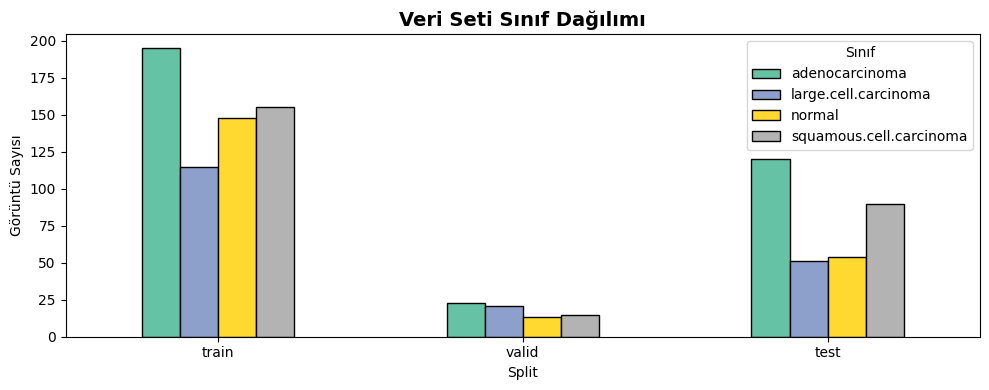

In [ ]:
def count_images(base_path):
    counts = {}
    for split in ['train', 'valid', 'test']:
        split_path = os.path.join(base_path, split)
        if not os.path.isdir(split_path):
            continue
        counts[split] = {}
        for cls in sorted(os.listdir(split_path)):
            cls_path = os.path.join(split_path, cls)
            if os.path.isdir(cls_path):
                counts[split][cls] = len(os.listdir(cls_path))
    return counts

counts = count_images(BASE_DIR)
df_counts = pd.DataFrame(counts).fillna(0).astype(int)
print("Görüntü Dağılımı:")
print(df_counts)
print(f"\nToplam: {df_counts.values.sum()} görüntü")

fig, ax = plt.subplots(figsize=(10, 4))
df_counts.T.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black')
ax.set_title('Veri Seti Sınıf Dağılımı', fontsize=14, fontweight='bold')
ax.set_xlabel('Split')
ax.set_ylabel('Görüntü Sayısı')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Sınıf')
plt.tight_layout()
plt.show()

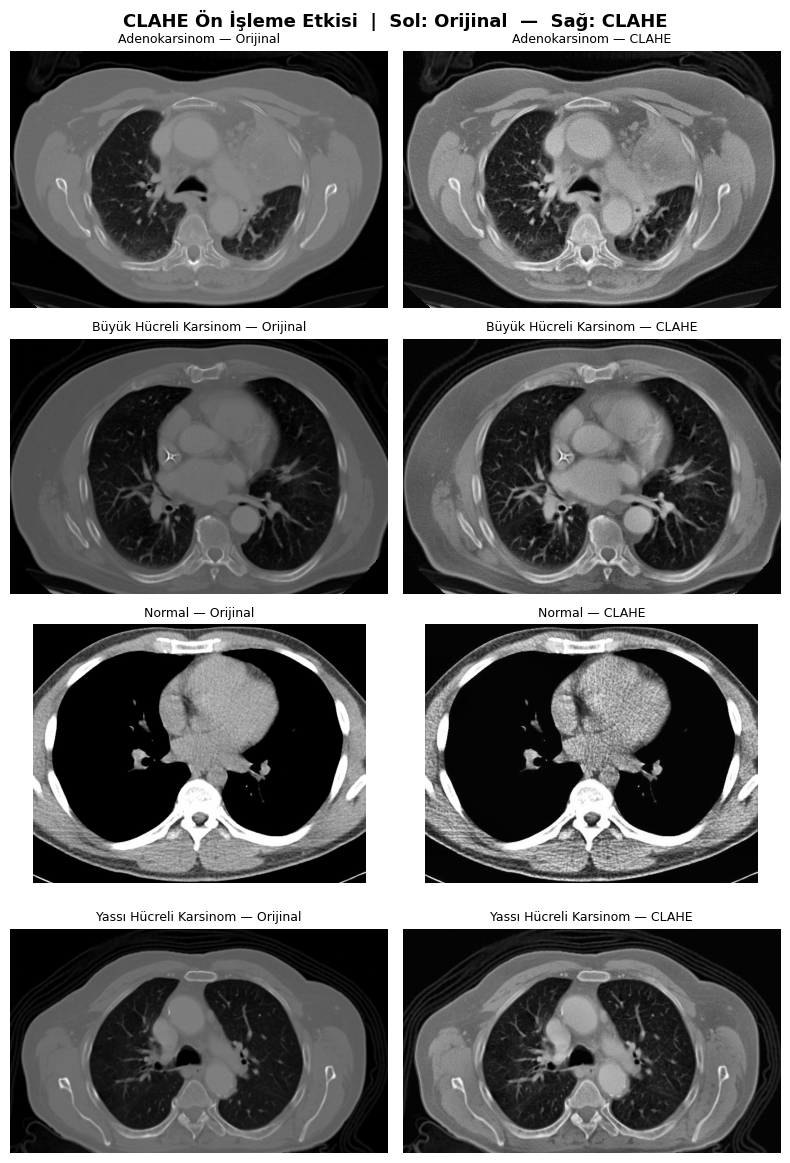

In [ ]:
def apply_clahe(img_bgr, clip_limit=2.0, tile_grid=(8, 8)):
    """
    LAB renk uzayında yalnızca L (parlaklık) kanalına CLAHE uygular.
    Renk bilgisi korunur, kontrast ve lezyon sınırları belirginleşir.
    """
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(img_lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    l_eq = clahe.apply(l)
    img_lab_eq = cv2.merge([l_eq, a, b])
    return cv2.cvtColor(img_lab_eq, cv2.COLOR_LAB2BGR)


def preprocess_with_clahe(img_array):
    """ImageDataGenerator için preprocessing_function."""
    img_uint8 = (img_array * 255).astype(np.uint8)
    img_clahe = apply_clahe(img_uint8)
    return img_clahe.astype(np.float32) / 255.0


# CLAHE etkisini görsel olarak karşılaştır
sample_classes = [
    c for c in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, c))
]

fig, axes = plt.subplots(len(sample_classes), 2,
                         figsize=(8, 3 * len(sample_classes)))
fig.suptitle('CLAHE Ön İşleme Etkisi  |  Sol: Orijinal  —  Sağ: CLAHE',
             fontsize=13, fontweight='bold')

for i, cls in enumerate(sample_classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_orig = cv2.imread(os.path.join(cls_path, img_name))
    img_proc = apply_clahe(img_orig)

    axes[i, 0].imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f'{CLASS_TR.get(cls, cls)} — Orijinal', fontsize=9)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(cv2.cvtColor(img_proc, cv2.COLOR_BGR2RGB))
    axes[i, 1].set_title(f'{CLASS_TR.get(cls, cls)} — CLAHE', fontsize=9)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_with_clahe,
    rotation_range         = 15,
    width_shift_range      = 0.1,
    height_shift_range     = 0.1,
    shear_range            = 0.05,
    zoom_range             = 0.1,
    horizontal_flip        = True,
    brightness_range       = [0.85, 1.15],
    fill_mode              = 'reflect'
)

eval_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_with_clahe
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = True,
    seed        = SEED
)

val_gen = eval_datagen.flow_from_directory(
    VAL_DIR,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)

test_gen = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size = (IMG_SIZE, IMG_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)

idx_to_class = {v: k for k, v in train_gen.class_indices.items()}
print("Sınıf → Index:", train_gen.class_indices)

Found 613 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Sınıf → Index: {'adenocarcinoma': 0, 'large.cell.carcinoma': 1, 'normal': 2, 'squamous.cell.carcinoma': 3}


In [ ]:
def build_efficientnet_model(num_classes=4, img_size=300,
                              dropout_rate=0.4, freeze_base=True):
    inputs = layers.Input(shape=(img_size, img_size, 3), name='input_ct')

    base_model = EfficientNetB3(
        include_top  = False,
        weights      = 'imagenet',
        input_tensor = inputs,
        pooling      = None
    )
    base_model.trainable = not freeze_base

    x = base_model.output
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dropout(dropout_rate, name='dropout_1')(x)
    x = layers.Dense(256, activation='relu', name='fc_256')(x)
    x = layers.BatchNormalization(name='bn_fc')(x)
    x = layers.Dropout(dropout_rate / 2, name='dropout_2')(x)
    outputs = layers.Dense(num_classes, activation='softmax',
                           name='predictions')(x)

    model = Model(inputs=inputs, outputs=outputs,
                  name='EfficientNetB3_LungCancer')
    return model, base_model


model, base_model = build_efficientnet_model(freeze_base=True)

print(f"Toplam parametre       : {model.count_params():,}")
print(f"Eğitilebilir parametre : {sum(tf.size(w).numpy() for w in model.trainable_weights):,}")
print(f"Dondurulmuş parametre  : {sum(tf.size(w).numpy() for w in model.non_trainable_weights):,}")

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Toplam parametre       : 11,185,203
Eğitilebilir parametre : 398,084
Dondurulmuş parametre  : 10,787,119


In [ ]:
labels_flat = train_gen.classes
class_weights_array = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(labels_flat),
    y            = labels_flat
)
class_weight_dict = dict(enumerate(class_weights_array))
print("Sınıf Ağırlıkları:", class_weight_dict)

model.compile(
    optimizer = Adam(learning_rate=LR_INITIAL),
    loss      = CategoricalCrossentropy(label_smoothing=0.1),
    metrics   = [
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model_phase1.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("\nFaz 1 Eğitimi Başlıyor...")
history1 = model.fit(
    train_gen,
    epochs          = 20,
    validation_data = val_gen,
    class_weight    = class_weight_dict,
    callbacks       = callbacks_phase1,
    verbose         = 1
)

Sınıf Ağırlıkları: {0: np.float64(0.7858974358974359), 1: np.float64(1.3326086956521739), 2: np.float64(1.035472972972973), 3: np.float64(0.9887096774193549)}

Faz 1 Eğitimi Başlıyor...
Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.3258 - auc: 0.5771 - loss: 2.0857 - precision: 0.3390 - recall: 0.2704 
Epoch 1: val_accuracy improved from None to 0.20833, saving model to best_model_phase1.keras

Epoch 1: finished saving model to best_model_phase1.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 240s 11s/step - accuracy: 0.3442 - auc: 0.6131 - loss: 1.8907 - precision: 0.3723 - recall: 0.2806 - val_accuracy: 0.2083 - val_auc: 0.5322 - val_loss: 1.4177 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.4162 - auc: 0.6674 - loss: 1.5596 - precision: 0.4705 - recall: 0.2960
Epoch 2: val_accuracy improved from 0.20833 to 0.29167, saving model to best_model_phase1.keras

Epoch 2: finished saving model to

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:FINETUNE_FROM]:
    layer.trainable = False

print(f"İnce ayar aktif katman: {sum(1 for l in model.layers if l.trainable)}")

model.compile(
    optimizer = Adam(learning_rate=LR_FINETUNE),
    loss      = CategoricalCrossentropy(label_smoothing=0.05),
    metrics   = [
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_model_final.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("\nFaz 2 (Fine-Tuning) Başlıyor...")
history2 = model.fit(
    train_gen,
    epochs          = EPOCHS,
    validation_data = val_gen,
    class_weight    = class_weight_dict,
    callbacks       = callbacks_phase2,
    verbose         = 1
)

İnce ayar aktif katman: 292

Faz 2 (Fine-Tuning) Başlıyor...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.4750 - auc: 0.7634 - loss: 1.3086 - precision: 0.5391 - recall: 0.3956 
Epoch 1: val_accuracy improved from None to 0.29167, saving model to best_model_final.keras

Epoch 1: finished saving model to best_model_final.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 490s 21s/step - accuracy: 0.5155 - auc: 0.7884 - loss: 1.2142 - precision: 0.5785 - recall: 0.4209 - val_accuracy: 0.2917 - val_auc: 0.6134 - val_loss: 1.4331 - val_precision: 0.3846 - val_recall: 0.1389 - learning_rate: 1.0000e-04
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.5495 - auc: 0.8152 - loss: 1.0994 - precision: 0.6534 - recall: 0.4551 
Epoch 2: val_accuracy did not improve from 0.29167
20/20 ━━━━━━━━━━━━━━━━━━━━ 405s 20s/step - accuracy: 0.5530 - auc: 0.8106 - loss: 1.1090 - precision: 0.6475 - recall: 0.4584 - val_accuracy: 0.2917 - val_auc: 0.5842 - val_loss: 1.5091 - val_precision: 0.26

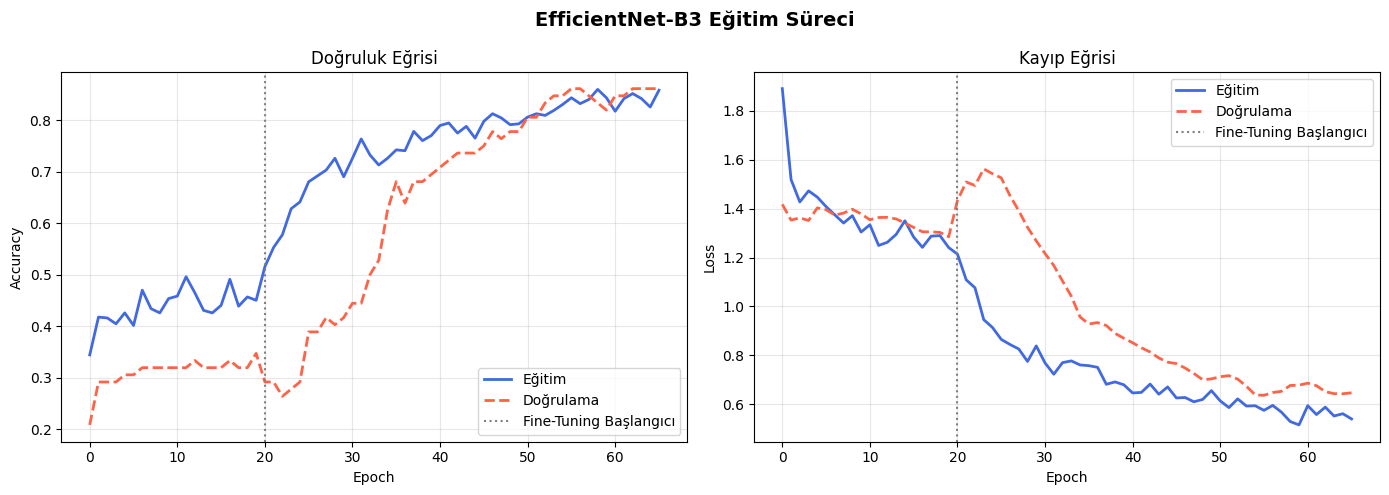

In [ ]:
def merge_histories(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history.get(key, [])
    return merged

hist = merge_histories(history1, history2)
phase1_len = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EfficientNet-B3 Eğitim Süreci', fontsize=14, fontweight='bold')

axes[0].plot(hist['accuracy'],     label='Eğitim',    color='royalblue', lw=2)
axes[0].plot(hist['val_accuracy'], label='Doğrulama', color='tomato',    lw=2, linestyle='--')
axes[0].axvline(phase1_len, color='gray', linestyle=':', label='Fine-Tuning Başlangıcı')
axes[0].set_title('Doğruluk Eğrisi')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hist['loss'],     label='Eğitim',    color='royalblue', lw=2)
axes[1].plot(hist['val_loss'], label='Doğrulama', color='tomato',    lw=2, linestyle='--')
axes[1].axvline(phase1_len, color='gray', linestyle=':', label='Fine-Tuning Başlangıcı')
axes[1].set_title('Kayıp Eğrisi')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('egitim_egrileri.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
test_gen.reset()
y_pred_proba = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_gen.classes

class_labels_tr = [
    CLASS_TR.get(idx_to_class[i], idx_to_class[i])
    for i in range(NUM_CLASSES)
]

report = classification_report(
    y_true, y_pred,
    target_names = class_labels_tr,
    digits       = 4
)
print("=" * 60)
print("     SINIFLANDIRMA RAPORU (Test Seti)")
print("=" * 60)
print(report)

10/10 ━━━━━━━━━━━━━━━━━━━━ 107s 9s/step
     SINIFLANDIRMA RAPORU (Test Seti)
                        precision    recall  f1-score   support

         Adenokarsinom     0.7410    0.8583    0.7954       120
Büyük Hücreli Karsinom     0.8421    0.6275    0.7191        51
                Normal     1.0000    0.9815    0.9907        54
Yassı Hücreli Karsinom     0.7176    0.6778    0.6971        90

              accuracy                         0.7905       315
             macro avg     0.8252    0.7863    0.8006       315
          weighted avg     0.7951    0.7905    0.7884       315



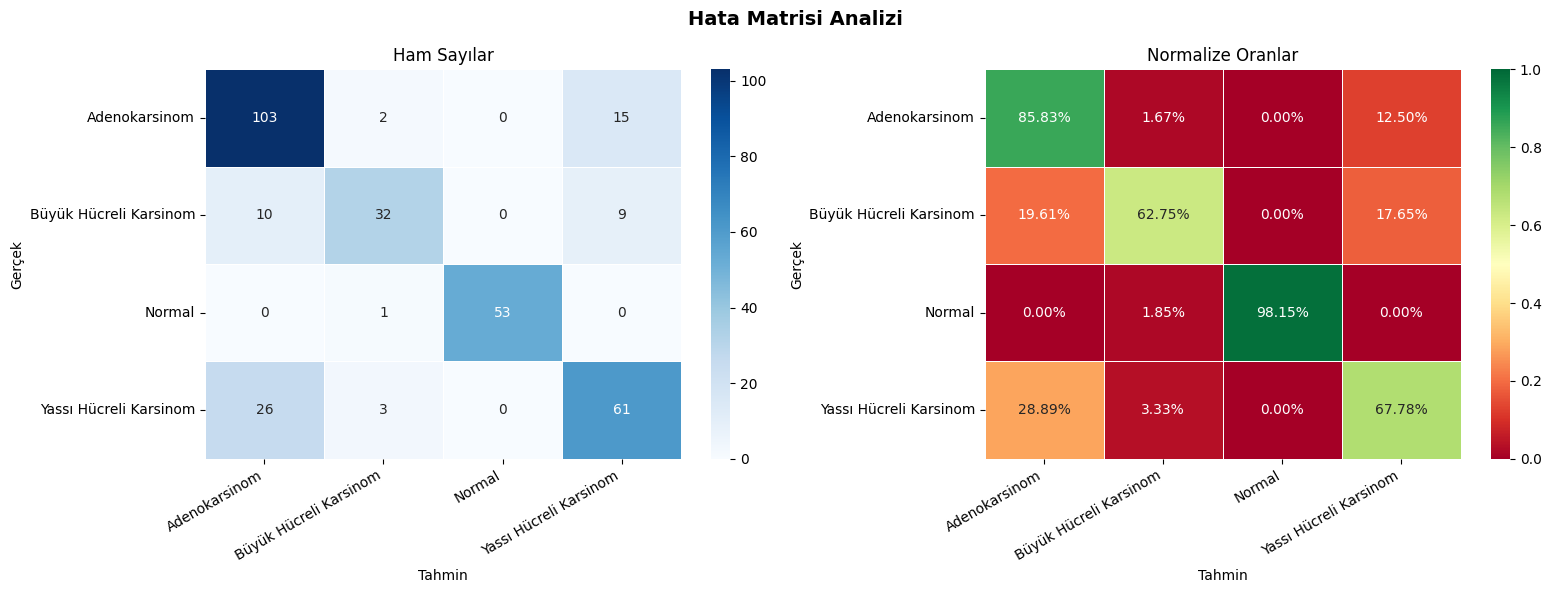

In [ ]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hata Matrisi Analizi', fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_tr, yticklabels=class_labels_tr,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Ham Sayılar')
axes[0].set_xlabel('Tahmin')
axes[0].set_ylabel('Gerçek')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn',
            xticklabels=class_labels_tr, yticklabels=class_labels_tr,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Normalize Oranlar')
axes[1].set_xlabel('Tahmin')
axes[1].set_ylabel('Gerçek')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None
)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)
overall_acc = np.mean(y_pred == y_true)

df_metrics = pd.DataFrame({
    'Hücre Tipi / Sınıf'  : class_labels_tr,
    'Kesinlik (Precision)' : precision.round(4),
    'Duyarlılık (Recall)'  : recall.round(4),
    'F1-Skor'              : f1.round(4),
    'Destek (Support)'     : support
})

macro_row = pd.DataFrame([{
    'Hücre Tipi / Sınıf'  : 'Makro Ortalama / Genel',
    'Kesinlik (Precision)' : round(macro_p, 4),
    'Duyarlılık (Recall)'  : round(macro_r, 4),
    'F1-Skor'              : round(macro_f1, 4),
    'Destek (Support)'     : int(sum(support))
}])

df_metrics = pd.concat([df_metrics, macro_row], ignore_index=True)

print(f"\n{'='*65}")
print(f" GENEL DOĞRULUK: {overall_acc:.4f}  ({overall_acc*100:.2f}%)")
print(f"{'='*65}")
print(df_metrics.to_string(index=False))


 GENEL DOĞRULUK: 0.7905  (79.05%)
    Hücre Tipi / Sınıf  Kesinlik (Precision)  Duyarlılık (Recall)  F1-Skor  Destek (Support)
         Adenokarsinom                0.7410               0.8583   0.7954               120
Büyük Hücreli Karsinom                0.8421               0.6275   0.7191                51
                Normal                1.0000               0.9815   0.9907                54
Yassı Hücreli Karsinom                0.7176               0.6778   0.6971                90
Makro Ortalama / Genel                0.8252               0.7863   0.8006               315
